In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
df = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")
df["date"] = pd.to_datetime(df["date"])

In [21]:
# Check missing values
print(df.isnull().sum())

# Sort by date (VERY IMPORTANT for time series)
df = df.sort_values("date")

# Remove duplicates if any
df = df.drop_duplicates()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [22]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

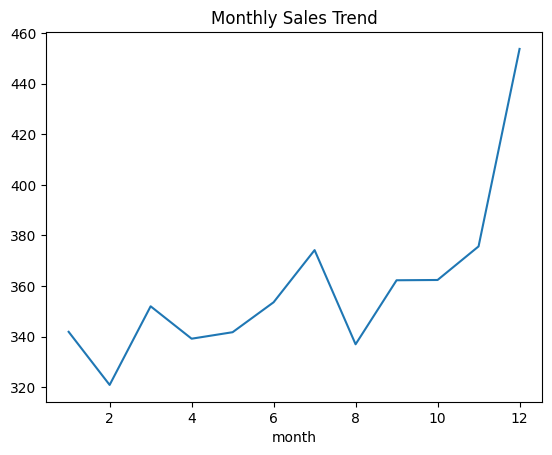

In [23]:
df.groupby("month")["sales"].mean().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [24]:
X = df[["store_nbr","onpromotion","year","month","day"]]
y = df["sales"]

X = pd.get_dummies(X)

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [26]:
train = df[df["date"] < "2017-01-01"]
test = df[df["date"] >= "2017-01-01"]

X_train = train[["store_nbr","onpromotion","year","month","day"]]
y_train = train["sales"]

X_test = test[["store_nbr","onpromotion","year","month","day"]]
y_test = test["sales"]

In [27]:
df["lag_1"] = df["sales"].shift(1)
df["lag_7"] = df["sales"].shift(7)
df["lag_14"] = df["sales"].shift(14)

df = df.dropna()

In [28]:
df["rolling_mean_7"] = df["sales"].rolling(window=7).mean()
df = df.dropna()

In [29]:
X = df[[
    "store_nbr","onpromotion","year","month","day",
    "lag_1","lag_7","lag_14","rolling_mean_7"
]]

In [30]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42)

In [31]:
pred = model.predict(X_test)

In [32]:
print("Gradient Boosting Regressor Results")
print("-------------------------------------")

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

Gradient Boosting Regressor Results
-------------------------------------
Mean Absolute Error (MAE): 494.7277518044063
R2 Score: 0.4521563638524748


In [33]:
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")

MAE: 494.73
R2 Score: 0.452


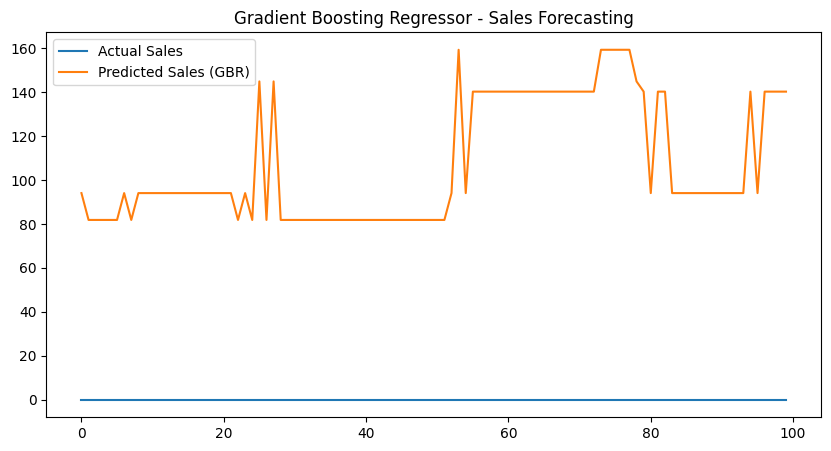

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(pred[:100], label="Predicted Sales (GBR)")
plt.title("Gradient Boosting Regressor - Sales Forecasting")
plt.legend()
plt.show()

**This project focuses on forecasting sales using historical retail data. Data preprocessing included handling missing values, sorting data by date, and creating time-based features such as lag values and rolling averages.
A Gradient Boosting Regressor model was used to predict sales, achieving a Mean Absolute Error (MAE) of 494.73 and an R² score of 0.45. The model captures key patterns in the data, including seasonal trends and the impact of promotions.
Overall, the project demonstrates how machine learning and feature engineering can be used to model and predict sales trends effectively.**